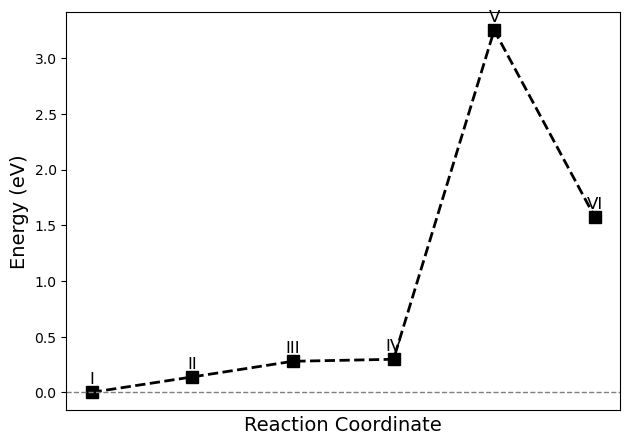

In [2]:
import matplotlib.pyplot as plt
import numpy as np

# Updated energy values from the last column (relative energies in eV)
images = np.arange(6)  # 0 to 8
energies = [0.000000, 0.1383, 0.2787, 0.2967, 3.2505, 1.5731]

# Roman numerals for labels
roman_labels = ['I', 'II', 'III', 'IV', 'V', 'VI', 'VII', 'VIII', 'IX']

# Plotting
# plt.figure(figsize=(10, 6))
plt.plot(images, energies, 'k--', marker='s', markersize=8, linewidth=2)

# Add horizontal reference line at E = 0 eV
plt.axhline(y=0, color='gray', linestyle='--', linewidth=1)

# Add Roman numeral labels on top of each image
for i, (x, y) in enumerate(zip(images, energies)):
    plt.text(x, y + 0.05, roman_labels[i], ha='center', va='bottom', fontsize=12)

plt.xlabel('Reaction Coordinate', fontsize=14)
plt.ylabel('Energy (eV)', fontsize=14)
plt.tight_layout()
plt.xticks([])
plt.show()

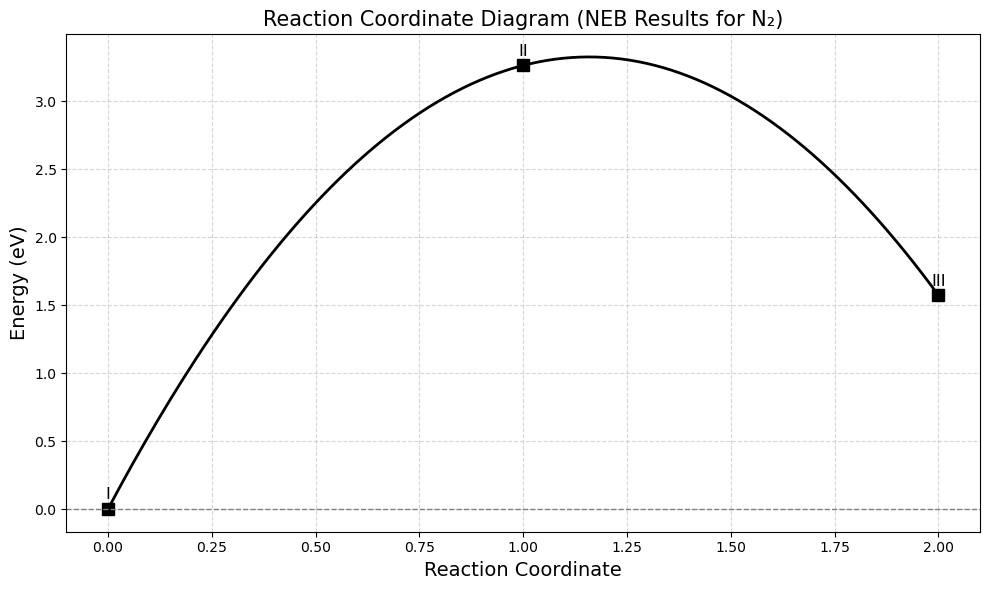

In [16]:
import matplotlib.pyplot as plt
import numpy as np

# Known data points
x_points = np.array([0, 1, 2])
y_points = np.array([0.000000, 3.264861, 1.5731])

# Fit a general 2nd degree polynomial (not forced to be symmetric)
coeffs = np.polyfit(x_points, y_points, deg=2)
poly = np.poly1d(coeffs)

# Generate a smooth curve
x_smooth = np.linspace(0, 2, 200)
y_smooth = poly(x_smooth)

# Roman numerals
roman_labels = ['I', 'II', 'III']

# Plot
plt.figure(figsize=(10, 6))
plt.plot(x_smooth, y_smooth, 'k-', linewidth=2)       # Smooth curve
plt.plot(x_points, y_points, 'ks', markersize=8)      # Data points

# Horizontal reference line
plt.axhline(y=0, color='gray', linestyle='--', linewidth=1)

# Add Roman numeral labels
for i, (x, y) in enumerate(zip(x_points, y_points)):
    plt.text(x, y + 0.05, roman_labels[i], ha='center', va='bottom', fontsize=12)

plt.xlabel('Reaction Coordinate', fontsize=14)
plt.ylabel('Energy (eV)', fontsize=14)
plt.title('Reaction Coordinate Diagram (NEB Results for N₂)', fontsize=15)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [31]:
def plot_rxn_coords(ax, energies, color, label, zero=None, linewidth=2, scale=0.32):
    energies = np.array(energies)
    if zero is not None:
        energies -= energies[zero]
    for j,l in enumerate(energies):
        ax.plot([(j+1-scale), (j+1+scale)], [l, l], color=color, linewidth=linewidth)
        if j <= len(energies)-2:
            ax.plot([(j+1+scale), (j+2-scale)], [l, energies[j+1]], linestyle=":", color=color, linewidth=linewidth)
    ax.plot([],[],color=color, linewidth=linewidth, label=label)
    
    
def plot_rxn_delta_es(ax, energies, color, label, width=0.25, shift=0, add_labels=False, fmt='%0.2f', 
                      label_padding=3, add_zero_line=True, linewidth=1, linestyle=':'):
    x = np.arange(len(energies) - 1) + 1  
    deltas = energies[1:] - energies[:-1]
    rects = ax.bar(x + shift, deltas, width, label=label, color=color)
    if add_labels:
        ax.bar_label(rects, padding=label_padding, fmt=fmt)
    if add_zero_line:
        ax.axhline(linewidth=linewidth, linestyle=linestyle, color='k')

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


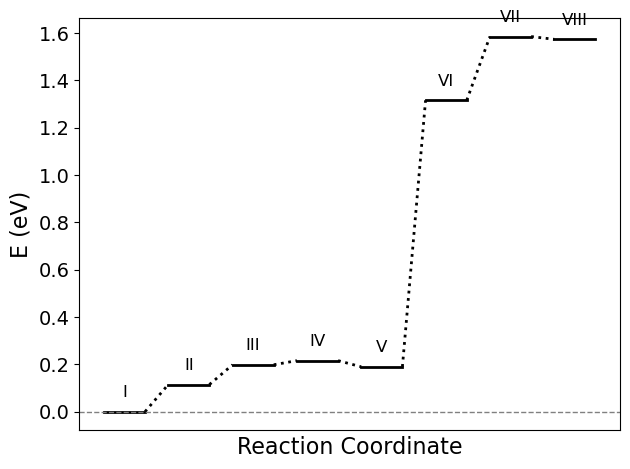

In [40]:
fig2 = plt.figure()
ax2 = fig2.add_subplot(111)
width=0.5
images = np.arange(9)  # 0 to 8
energies = [0.000000, 0.114500, 0.198200, 0.215700,
            0.189600, 1.315400, 1.584700, 1.573100]


plot_rxn_coords(ax2, energies, 'black', None, zero=0, linewidth=2, scale=0.32)

# Roman numerals for labels
roman_labels = ['I', 'II', 'III', 'IV', 'V', 'VI', 'VII', 'VIII', 'IX']
for i, (x, y) in enumerate(zip(images, energies)):
    plt.text(x+1, y + 0.05, roman_labels[i], ha='center', va='bottom', fontsize=12)
    
ax2.set_ylabel('E (eV)', fontsize=16)
ax2.set_xlabel('Reaction Coordinate', fontsize=16)
ax2.set_xticks([])
ax2.tick_params(labelsize=14)
ax2.legend(loc="lower left", frameon=False, fontsize=14)
plt.axhline(y=0, color='gray', linestyle='--', linewidth=1)

plt.tight_layout()
plt.show()
# fig2.savefig(f'es.png', dpi=300)
# plt.close(fig2)

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


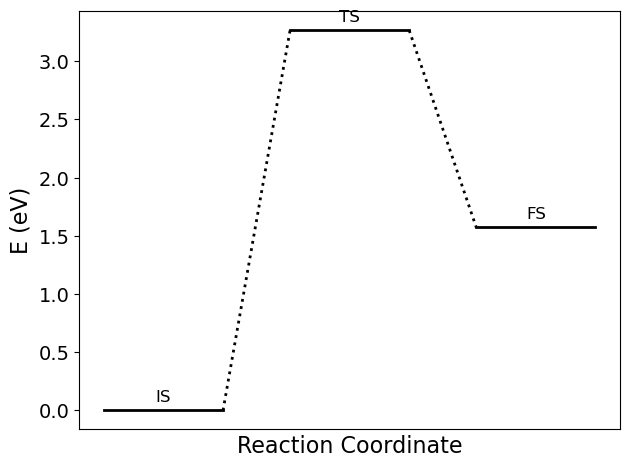

In [43]:
energies = [0,3.2648,1.5731]
fig2 = plt.figure()
ax2 = fig2.add_subplot(111)
width=0.5

images = np.arange(3)  # 0 to 8
energies = [0,3.2648,1.5731]

plot_rxn_coords(ax2, energies, 'black', None, zero=0, linewidth=2, scale=0.32)

roman_labels = ['IS', 'TS', 'FS']
for i, (x, y) in enumerate(zip(images, energies)):
    plt.text(x+1, y + 0.05, roman_labels[i], ha='center', va='bottom', fontsize=12)
    
ax2.set_ylabel('E (eV)', fontsize=16)
ax2.set_xlabel('Reaction Coordinate', fontsize=16)
ax2.set_xticks([])
ax2.tick_params(labelsize=14)
ax2.legend(loc="lower left", frameon=False, fontsize=14)
plt.tight_layout()
plt.show()

In [44]:
import numpy as np
from scipy.interpolate import make_interp_spline
def TS_interpolation_aux(_Energies_PES):
    _TS_interpolation_function = make_interp_spline([0, 0.5, 1],
                                                   [_Energies_PES[0], _Energies_PES[1], _Energies_PES[2]],
                                                   bc_type=([(1, 0.0)], [(1, 0.0)])
                                                   )
    _X_TS_xline = np.linspace(0, 1, 500)
    _Y_TS_xline = _TS_interpolation_function(_X_TS_xline)
    return _X_TS_xline, _Y_TS_xline

Text(0, 0.5, 'E (eV)')

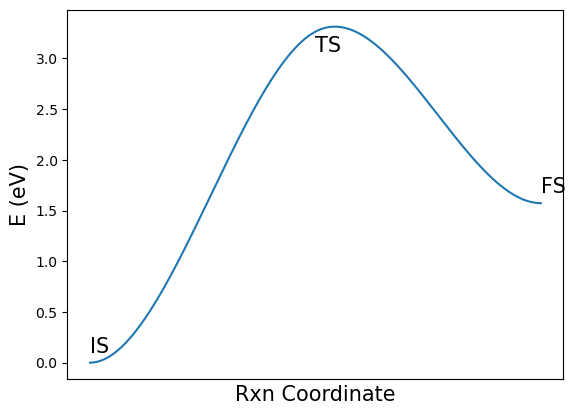

In [82]:
energies = [0,3.2648,1.5731]
x, y = TS_interpolation_aux(energies)
plt.plot(x,y)
labels = ['IS', 'TS', 'FS']
plt.text(0,y[0]+0.1,labels[0],fontsize=15)
plt.text(0.5,y[int(len(x)/2)]-0.2,labels[1],fontsize=15)
plt.text(1,y[-1]+0.1,labels[2],fontsize=15)
plt.xticks([])
plt.xlabel('Rxn Coordinate', fontsize=15)
plt.ylabel('E (eV)', fontsize=15)

ValueError: x and y must have same first dimension, but have shapes (100,) and (17,)

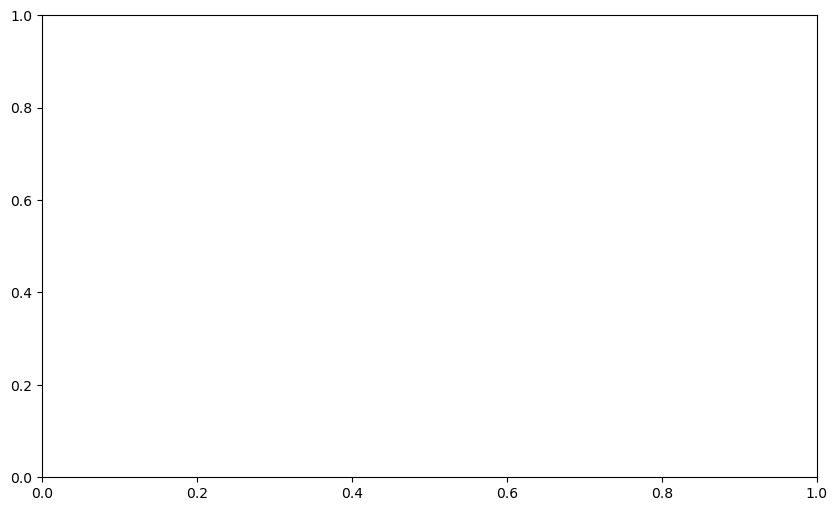

In [2]:
import matplotlib.pyplot as plt
import numpy as np

# Sample data for a multi-step reaction
x = np.linspace(0, 1, 100)  # Reaction coordinate (0 to 1, for example)
y = []

# Reactant state (initial energy)
y.append(0)

# Step 1: Reactants to transition state 1
y.extend(np.array([0, 10, 0]) + np.array(np.linspace(0, 10, 3)))

# Transition state 1
y.append(10)

# Step 2: Transition state 1 to intermediate 1
y.extend(np.array([10, 15, 10]) + np.array(np.linspace(10, 15, 3)))

# Intermediate 1
y.append(15)

# Step 3: Intermediate 1 to transition state 2
y.extend(np.array([15, 20, 15]) + np.array(np.linspace(15, 20, 3)))

# Transition state 2
y.append(20)

# Step 4: Transition state 2 to products
y.extend(np.array([20, 10, 0]) + np.array(np.linspace(20, 10, 3)))

# Product state (final energy)
y.append(0)

# Convert list to numpy array for plotting
y = np.array(y)

# Plotting the reaction coordinate diagram
plt.figure(figsize=(10, 6))  # Adjust figure size as needed
plt.plot(x, y, color='blue', linewidth=2, label='Reaction Path')

# Add labels and title
plt.xlabel('Reaction Coordinate')
plt.ylabel('Energy (kcal/mol)')  # Adjust units as needed
plt.title('Reaction Coordinate Diagram')

# Add labels for reactants and products
plt.scatter(x[0], y[0], color='green', marker='o', s=50, label='Reactants')
plt.scatter(x[-1], y[-1], color='red', marker='o', s=50, label='Products')

# Add labels for transition states and intermediates
plt.scatter(x[3], y[3], color='orange', marker='x', s=100, label='Transition State 1')
plt.scatter(x[9], y[9], color='purple', marker='x', s=100, label='Intermediate 1')
plt.scatter(x[16], y[16], color='cyan', marker='x', s=100, label='Transition State 2')

# Customize the plot (optional)
plt.xlim(0, 1)
plt.ylim(0, 25)
plt.grid(True, linestyle='--')  # Add grid lines

# Display legend
plt.legend()

# Show the plot
plt.show()

In [6]:
x

[1, 2, 3, 4, 5, 6, 7]